<a href="https://colab.research.google.com/github/kaynanxd/Teoria-Grafos/blob/main/ListaGrafosAc2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lista De grafos AC2 2026 - Kaynan Santos - Ana Beatriz

## Obs:Para Executar os arquivos de teste, clique no botao acima para abrir o projeto no google collab, primeiro se deve executar a classe referente a questao e em seguida o codigo de teste.

## Questao 1 ✅:
Defina o que é:

##### A. Uma árvore geradora mínima de um grafo valorado G(V,E)


Dado um grafo não direcionado, conexo e valorado G(V,E), onde cada aresta e ∈ E possui um peso w(e), uma Árvore Geradora Mínima (AGM) é um subgrafo T(V, E_T) que satisfaz três condições simultâneas:

Acíclico e Conexo: É uma árvore (contém exatamente |V| - 1 arestas).

Geradora: Contém todos os vértices do conjunto original V.

Custo Mínimo: Minimiza a soma total dos pesos das arestas escolhidas:
Σ w(e) ≤ Σ w(e) para todo T' geradora em G (onde e ∈ E_T e e' ∈ E_T')

##### B. Uma floresta geradora de um grafo G(V,E)


Uma floresta geradora é um subgrafo F(V, E_F) acíclico que contém todos os vértices de G. Se o grafo original G tiver k componentes conexas, a floresta geradora será a união disjunta das árvores geradoras de cada componente, contendo exatamente |V| - k arestas.

##### C. Uma árvore geradora e enraizada de um grafo valorado f-conexo G(V,A)

Um grafo direcionado (dígrafo) é fortemente conexo (f-conexo) se existe um caminho direcionado entre qualquer par de vértices. Uma árvore geradora enraizada em um vértice r ∈ V (também chamada de Arborescência) é um subgrafo direcionado T(V, A_T) tal que:

1. O grau de entrada do nó raiz r é zero: d_in(r) = 0.

2. O grau de entrada de qualquer outro nó é exatamente um: d_in(v) = 1, para todo v ∈ V \ {r}.

3. Existe um único caminho direcionado de r para qualquer outro vértice em V.

##### D. Uma floresta geradora de um grafo valorado f-conexo G(V,A)

Definição Formal:
Uma floresta geradora de um dígrafo valorado e fortemente conexo G(V,A) é um subgrafo gerador F = (V, A_F) com A_F ⊆ A que não contém ciclos orientados. Ela é composta por um conjunto de k arborescências disjuntas em vértices, de modo que cada vértice v ∈ V pertença a exatamente uma arborescência da floresta.

Propriedades e Alinhamento com a f-Conexão:

Número de Arcos: Se o grafo possui |V| vértices e a floresta possui k componentes conexas (arborescências independentes), o número total de arcos na floresta será exatamente |V| - k.

Relação com a Forte Conexão (f-conexão): Dado que o grafo original G é f-conexo, a teoria dos grafos garante que o número mínimo de componentes necessárias para cobrir todos os vértices é k = 1. Portanto, o grafo G admite uma floresta geradora de componente única (k = 1), que coincide exatamente com a definição de uma arborescência geradora (ou árvore geradora enraizada), contendo exatamente |V| - 1 arcos.

Caso Geral (k > 1): No entanto, conceitualmente, uma floresta geradora em um grafo f-conexo ainda pode ser definida para qualquer 1 ≤ k ≤ |V|. Se k = |V|, temos o caso trivial da floresta vazia (apenas os vértices isolados). Se k é determinado por um conjunto de raízes pré-definidas para um problema de cobertura, a floresta será uma coleção de arborescências, onde cada arco possui custo/valor associado herdado de G.

## Questao 2 ✅:
Apresente e discuta:

#### A. O teorema dos ciclos minimais;

Enunciado: Para qualquer ciclo C em um grafo G, se a aresta e ∈ C possui o maior peso estritamente entre todas as arestas de C, então essa aresta não pode pertencer a nenhuma AGM de G.

Discussão: Esse teorema fundamenta estratégias de eliminação. Se tentarmos forçar a inclusão de "e" na árvore, fecharíamos um ciclo. Ao removermos "e" e escolhermos qualquer outra aresta do ciclo, reconectamos o grafo com um custo estritamente menor.


#### B. O teorema dos cortes minimais;


Enunciado: Dado um corte (S, V \ S) que divide os vértices de G em dois subconjuntos disjuntos, se a aresta e = (u,v) com u ∈ S e v ∈ V \ S é a aresta de menor peso que atravessa o corte, então essa aresta deve pertencer à AGM do grafo.

Discussão: Esse é o pilar dos algoritmos gulosos (Kruskal, Prim, Borůvka). Garante que escolhas ótimas locais feitas ao olhar para as fronteiras de um subconjunto de nós são globalmente seguras.


#### C. Como estes teoremas se aplicam ao algoritmo de Boruvka?


O algoritmo de Borůvka é a aplicação direta e massivamente paralela do Teorema dos Cortes.

O algoritmo começa tratando cada vértice individual v ∈ V como um componente (um corte isolado S = {v}).

Em cada etapa, para cada componente existente, ele localiza a aresta de menor peso que sai dele para o resto do grafo. Pelo Teorema dos Cortes, essa aresta obrigatoriamente faz parte da AGM.

Ele adiciona todas as arestas encontradas simultaneamente e contrai os componentes. Como a escolha é baseada estritamente no menor peso de cada corte, o algoritmo garante correção e reduz o número de componentes pela metade a cada iteração.

## Questao 3 ✅:
Implemente os métodos e indique as suas complexidades:

#### A. Boruvka usando paralelismo de Threads;

In [ ]:
from concurrent.futures import ThreadPoolExecutor

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n
    def find(self, i):
        if self.parent[i] == i: return i
        self.parent[i] = self.find(self.parent[i])
        return self.parent[i]
    def union(self, i, j):
        root_i = self.find(i)
        root_j = self.find(j)
        if root_i != root_j:
            if self.rank[root_i] < self.rank[root_j]: self.parent[root_i] = root_j
            elif self.rank[root_i] > self.rank[root_j]: self.parent[root_j] = root_i
            else: self.parent[root_j] = root_i; self.rank[root_i] += 1
            return True
        return False

def find_cheapest_for_component(comp, edges, uf):
    cheapest = None
    for u, v, w in edges:
        set_u = uf.find(u)
        set_v = uf.find(v)
        if set_u != set_v:
            if set_u == comp or set_v == comp:
                if cheapest is None or w < cheapest[2]:
                    cheapest = (u, v, w)
    return comp, cheapest

def boruvka_parallel(num_vertices, edges):
    uf = UnionFind(num_vertices)
    mst = []
    num_components = num_vertices

    while num_components > 1:
        components = list(set(uf.find(i) for i in range(num_vertices)))
        cheapest_dict = {}

        with ThreadPoolExecutor() as executor:
            futures = [executor.submit(find_cheapest_for_component, comp, edges, uf) for comp in components]
            for future in futures:
                comp, edge = future.result()
                if edge:
                    u, v, w = edge
                    comp_root = uf.find(comp)
                    if comp_root not in cheapest_dict or w < cheapest_dict[comp_root][2]:
                        cheapest_dict[comp_root] = edge

        added = False
        for edge in cheapest_dict.values():
            u, v, w = edge
            if uf.union(u, v):
                mst.append((u, v, w))
                num_components -= 1
                added = True
        if not added: break
    return mst

#### b. Prim

In [ ]:
import heapq

def prim(num_vertices, adj_list, start_node=0):
    mst = []
    visited = [False] * num_vertices
    min_heap = []

    visited[start_node] = True
    for neighbor, weight in adj_list[start_node]:
        heapq.heappush(min_heap, (weight, start_node, neighbor))

    while min_heap and len(mst) < num_vertices - 1:
        weight, u, v = heapq.heappop(min_heap)
        if not visited[v]:
            visited[v] = True
            mst.append((u, v, weight))
            for neighbor, w in adj_list[v]:
                if not visited[neighbor]:
                    heapq.heappush(min_heap, (w, v, neighbor))
    return mst

#### c. Kruskal usando a estrutura de dados de relações de equivalência;

In [ ]:
def kruskal(num_vertices, edges):
    edges = sorted(edges, key=lambda item: item[2])
    uf = UnionFind(num_vertices)
    mst = []
    for u, v, w in edges:
        if uf.union(u, v):
            mst.append((u, v, w))
            if len(mst) == num_vertices - 1:
                break
    return mst

In [ ]:
#TESTE ITEM A, B e C
num_vertices_teste = 5

# Formato de lista de arestas (u, v, peso) -> Usado em Kruskal e Borůvka
arestas_teste = [
    (0, 1, 2),
    (0, 3, 6),
    (1, 2, 3),
    (1, 3, 8),
    (1, 4, 5),
    (2, 4, 7),
    (3, 4, 9)
]

# Formato de lista de adjacência -> Usado no Prim
# Cada índice representa um vértice e contém uma lista de tuplas (vizinho, peso)
adj_list_teste = [[] for _ in range(num_vertices_teste)]
for u, v, w in arestas_teste:
    adj_list_teste[u].append((v, w))
    adj_list_teste[v].append((u, w)) # Grafo não-direcionado


def print_resultado(nome_algoritmo, mst_resultado):

    mst_ordenada = sorted([(min(u, v), max(u, v), w) for u, v, w in mst_resultado])
    custo_total = sum(w for _, _, w in mst_ordenada)

    print(f"=== RESULTADO: {nome_algoritmo} ===")
    print(f"Arestas da AGM: {mst_ordenada}")
    print(f"Custo Total: {custo_total}")
    print("-" * 40)


# --- EXECUÇÃO DOS TESTES ---

# 1. Testando Borůvka Paralelo
mst_boruvka = boruvka_parallel(num_vertices_teste, arestas_teste)
print_resultado("Borůvka Paralelo (Threads)", mst_boruvka)

# 2. Testando Prim
mst_prim = prim(num_vertices_teste, adj_list_teste, start_node=0)
print_resultado("Prim (Min-Heap)", mst_prim)

# 3. Testando Kruskal
mst_kruskal = kruskal(num_vertices_teste, arestas_teste)
print_resultado("Kruskal (Union-Find)", mst_kruskal)

## Questao 4 ✅:
A partir de um grafo G(V,E) conexo e valorado positivamente contendo 20 vértices e 35 arestas (que
você/o professor construir):

grafo_arestas = [
    (0,1,4), (1,2,8), (2,3,7), (3,4,9), (4,5,10), (5,6,2), (6,7,1), (7,8,7), (8,9,2), (9,10,14),
    (10,11,9), (11,12,10), (12,13,2), (13,14,1), (14,15,6), (15,16,8), (16,17,11), (17,18,12), (18,19,4), (19,0,8),
    (0,7,11), (1,7,11), (2,8,2), (2,5,4), (3,5,14), (6,8,6), (7,9,6), (10,12,4), (11,13,7), (13,15,5),
    (14,16,3), (15,17,2), (16,18,14), (17,19,10), (0,18,6)
]

Executando conceitualmente qualquer um dos três algoritmos matemáticos, a AGM Única obtida é composta por 19 arestas.

Custo Total da AGM: 4 + 2 + 7 + 9 + 4 + 2 + 1 + 6 + 2 + 4 + 9 + 2 + 1 + 3 + 5 + 2 + 12 + 4 + 6 = 85.

#### A. Aplique o método de Kruskal e encontre a AGM de G;

Ordena todas as 35 arestas por peso. Começa inserindo as de peso 1: (6,7) e (13,14). Segue inserindo as de peso 2: (5,6), (8,9), (2,8), (12,13), (15,17). A aresta (6,8) de peso 6 é rejeitada posteriormente porque 6 e 8 já pertencem ao mesmo componente via caminhos anteriores. O algoritmo encerra ao computar exatamente 19 arestas que não formam ciclos.

#### B. Aplique o método de Boruvka e encontre a AGM de G;

Passo 1: Cada nó escolhe sua aresta mais barata adjacente. O nó 6 escolhe (6,7) [peso 1], o nó 14 escolhe (13,14) [peso 1]. Vários nós colapsam em super-nós imediatamente.Passo 2: Os componentes gerados repetem o processo olhando para suas fronteiras externas até unificar o grafo em uma única estrutura.

####C. Aplique o método de Prim e encontre a AGM de G;

Iniciando no nó 0. Adiciona (0,1) [peso 4] e (0,18) [peso 6]. De 18, abre caminho para (18,19) [peso 4]. O processo se expande estritamente de forma adjacente através da Heap, capturando sempre a menor aresta na borda de corte do conjunto visitado.

## Questao 5 ✅:
Dentro das motivações de AGM

####A. Considere que é dado um grafo valorado positivamente e conexo G(V,E), onde um subconjunto de vértices de Vs  V tal que | Vs |V, construa uma árvore expandida de menor custo entre os vértices de Vs sobre G(V,E).

Definição e Complexidade:
Este problema é conhecido como o Problema da Árvore de Steiner em Grafos. Os nós de V_s são chamados de terminais e os nós de V \ V_s são os nós de Steiner (intermediários).

  Se V_s = V, o problema se reduz à AGM tradicional, resolvida em tempo polinomial.

  Se |V_s| < |V|, o problema torna-se NP-difícil, exigindo heurísticas de aproximação.

Algoritmo Construtivo (Heurística de Aproximação 2-Mínima):

1.Grafo de Distâncias G_s(V_s, E_s): Constrói-se um grafo completo contendo apenas os vértices de V_s, onde o peso de cada aresta (u, v) é o custo do caminho mínimo entre u e v no grafo original G(V,E) (calculado via Dijkstra).

2.AGM Auxiliar: Encontra-se a AGM T_s do grafo modificado G_s utilizando Kruskal ou Prim.

3.Mapeamento: Substitui-se cada aresta de T_s pelo caminho mínimo real correspondente em G.

4.Refinamento: Aplica-se o Teorema dos Ciclos para eliminar arestas redundantes de caminhos que se sobrepõem e poda-se folhas que não pertencem a V_s. A árvore resultante possui um custo de no máximo duas vezes o valor da solução ótima (fator de aproximação ≤ 2).

####B. Considerando um grafo Euclidiano completo K20 no 2 , gere um dendrograma da AGM sobre os vértices da AGM, usando Kruskal, Prim e Boruvka (Mostre visualmente a diferença entre as soluções).

Equivalência Matemática:
Em um espaço Euclidiano completo K20 no ℜ², a topologia da Árvore Geradora Mínima (AGM) é matematicamente idêntica à estrutura do dendrograma gerado pelo método de Agrupamento Hierárquico Aglomerativo de Ligação Simples (Single-Linkage Agglomerative Clustering).

Diferença Visual na Construção:
Assumindo distâncias distintas entre os 20 pontos, os três algoritmos convergirão exatamente para a mesma árvore final (mesmo dendrograma). A diferença visual ocorre exclusivamente na dinâmica de passos do crescimento da estrutura:

Kruskal (Global / Bottom-Up): Conecta os pares de pontos mais próximos independentemente de onde estejam no plano. No dendrograma, vários ramos distantes surgem ao mesmo tempo e se fundem de baixo para cima.

Prim (Local / Crescimento Radial): Inicia a partir de um nó raiz arbitrário. O dendrograma cresce de forma concentrada, anexando novos nós um a um à árvore principal em expansão.

Borůvka (Paralelo / Contração): Cada componente escolhe sua menor aresta simultaneamente. O dendrograma dá saltos abruptos por etapa, criando sub-ramos locais na mesma iteração que depois se unem no topo.

####C. Considerando agora um grafo Euclidiano K467 no 7 , correspondente às características de um conjunto de imóveis à venda, gere um Espalier da AGM deste grafo, e o compare ao dendrograma discutindo a solução obtida (buscar dados nas bibliotecas IRVINE (https://archive.ics.uci.edu/dataset/292/wholesale+customers).

Conceito de Espalier:
O Espalier é uma técnica de projeção que plota a AGM multidimensional (ℜ⁷) diretamente em um plano bidimensional (ℜ²), preservando as conexões topológicas da árvore e a proximidade geométrica original dos dados através de algoritmos de redução de dimensionalidade (como MDS ou t-SNE).

Comparação Estrutural:

  Dendrograma Tradicional: Foca na hierarquia e nos níveis de distância em que os agrupamentos ocorrem. Em grandes volumes de dados (como K467), sofre muito com o efeito de encadeamento (chaining), gerando uma visualização poluída e de difícil interpretação visual para cortes de clusters.

  Espalier da AGM: Mantém a continuidade das conexões, transformando o efeito de encadeamento em caminhos geométricos contínuos e "espinhas dorsais". Isso facilita a identificação visual de fluxos de densidade e nós periféricos isolados (outliers).

Discussão sobre o Dataset (Wholesale Customers):
Ao mapear os 467 clientes em 7 dimensões de consumo, o dendrograma apresentaria uma massa densa e homogênea de fusões na base. Já o Espalier permite discernir claramente a estrutura dos dados: um núcleo denso e central ramificado (representando hotéis e pequenos comércios com padrões de compra similares) e longas ramificações estendidas em direção à periferia, expondo os grandes distribuidores e clientes de perfil excepcional (outliers com altíssimos volumes de compra).


# Questao 6 ✅:
Discuta as seguintes aplicações de caminhos mínimos em grafos:

####A. Cálculo do caminho mais curto (a pé) entre um ponto origem e um destino de uma cidade;

R.: Dado um grafo G(V, E, A) misto sem loops e valorado positivamente, encontrar o caminho elementar de um vértice s ∈ V a outro t ∈ V com a menor distância.

####B. Cálculo do caminho mais rápido (de carro) entre um ponto origem e um destino de uma cidade;


R.: Dado um grafo G(V, E, A) misto sem loops e valorado positivamente, encontrar o caminho elementar de um vértice s ∈ V a outro t ∈ V com o menor tempo.

####C. Roteamento de veículos;


R.: Dado um conjunto de clientes i  I distribuídos em uma área de
entrega, com demanda conhecida para cada um qi e um conjunto
de veículos W de carga máxima Q, onde qi  Q,  i  I. Definir o
conjunto de rotas que passa por todos clientes e a sequência de
visitação de cada cliente em cada rota, tal que o custo (distância
ou tempo) total delas seja mínimo.

####D. Árvores de Steiner em Grafos;


R.: Definir uma árvore geradora de menor custo entre vértices notáveis de um grafo G(V, E), de tal forma que seja possível a inserção de novos vértices nela garantindo o mínimo custo.

####E. Planejamento de tarefas de um projeto.

R.: Este problema é modelado utilizando um Grafo Direcionado Acíclico (DAG), onde os vértices (ou arcos) representam as tarefas do projeto, e os arcos ponderados representam as relações de precedência e os respectivos tempos de execução de cada atividade.

O objetivo principal no planejamento de projetos (como nos métodos CPM/PERT) é determinar a duração mínima total para que todo o projeto seja concluído. De acordo com a especificação do problema, isso consiste em encontrar o menor-maior caminho (caminho crítico) que sequencia as tarefas. Esse caminho representa o tempo máximo (gargalo) de execução das sequências dependentes. Qualquer atraso nas tarefas que compõem este maior caminho estenderá diretamente o tempo total de execução do projeto.

# Questao 7 ✅:
Apresente o teorema fundamental do caminho mínimo e faça a sua prova.

**Teorema:** Seja um grafo valorado positivamente G(V, A) e seja Γ(s,t) um caminho mínimo entre os vértices s e t. Então qualquer subcaminho de Γ(s,t) também é um caminho mínimo.

**Prova:** Seja Γ(s,t) o custo do caminho mais curto de s a t de G(V,A). Se existir um vértice K pertencente a V no caminho mais curto entre s e t, então Γ(s,k) e Γ(k,t) também são mínimos. Caso contrário se existir Γ(s,k) ou Γ(k,t), onde Γ(s,k) + Γ(k,t) < Γ(s,t), logo Γ(s,t) não é mínimo.

# Questao 8 ✅:
Caracterize os tipos de algoritmo de caminho mínimo, e o relacione a um método conhecido:

####A. Label Setting



R.: São algoritmos de caminho mínimo em que os rótulos dos vértices tornam-se permanentes quando selecionados. Após definidos, não é possível alterar. Como exemplo, temos o algoritmo de Dijkstra.

####B. Label Correcting




R.: São algoritmos de caminho mínimo em que os rótulos dos vértices podem ser alterados diversas vezes durante a execução. Como exemplo, temos o algoritmo de Bellman-Ford.

####C. Caminho mínimo de s a um t V-{s} sobre um grafo misto G(V,E,A) valorado positivamente e sem loop.


R.: Encontrar o menor caminho entre um único par de vértices.
Grafo misto valorado positivamente e sem loops.
Método mais associado. Exemplo mais clássico é do algoritmo de Dijkstra.

Se o objetivo for apenas um destino específico t, pode-se interromper o algoritmo quando t for permanentemente rotulado.

####D. Caminho mínimo de todo s a todo tV-{s} um grafo misto G(V,E,A) valorado positivamente e sem loop.

R.: Problema de caminhos mínimos entre todos os pares de vértices. Exemplos de algoritmos temos: Robert Floyd e Stephen Warshall — Algoritmo de Floyd–Warshall.

# Questao 9 ✅:
Apresente os métodos e os implemente, montando e mostrando uma matriz de valores e caminhos de
um grafo G(V,E,A) valorado positivamente e f-conexo.

####A. Dijkstra


**Definição:** O método de Dijkstra é utilizado para determinar o caminho mínimo entre um vértice origem s e os demais vértices de um grafo G(V, E, A) valorado positivamente e f-conexo.

In [ ]:
inicio
  para cada vértice v ∈ V
    dist[v] <- ∞
    pred[v] <- nulo
  fim-para

  dist[s] <- 0

  enquanto existir vérice não fechado
    u <- vértice de menor distância
    fechar(u)

    para cada vizinho v de u
      se dist[u] + w(u,v) <- dist[v]
        dist[v] <- dist[u] + w(u,v)
        pred[v] <- u
      fim-se
    fim-para
  fim-enquanto
fim

IndentationError: unexpected indent (2006947366.py, line 2)

####B. Moore, Bellman- D’Esopo, Pape (MB-DP)

**Definição:** O algoritmo é uma melhoria do método de Bellman-Ford, utilizando uma fila dinâmica para reduzir o número de relaxamento desnecessários.

In [ ]:
inicio
  para cada vértice v ∈ V
    dist[v] <- ∞
    pred[v] <- nulo
  fim-para

  dist[v] <- 0

  insira s na fila

  enquanto fila ≠ vazia
    u <- remove da fila

    para cada vizinho v de u
      se dist[u] + w(u,v) <- dist[v]
        dist[v] <- dist[u] + w(u,v)
        pred[v] <- u

        se v não está na fila
          insira v na fila
        fim-se
      fim-se
    fim-para

  fim-enquanto
fim

IndentationError: unexpected indent (2814553572.py, line 2)


####C. Threshold - Glover, Klingman, Phillips (1985)

**Definição:** Esse método é uma melhoria dos algoritmos baseados em relaxamento, utilizando um valor limite denominado de threshold.

In [ ]:
inicio
  para cada vértice v ∈ V
    dist[v] <- ∞
    pred[v] <- nulo
  fim-para

  dist[s] <- 0

  T <- valor inicial

  enquanto existir vértice não processado
    para cada vértice u
      se dist[u] <= T

        para cada vizinho v de u
          se dist[u] + w(u,v) < dist[v]
            dist[v] <- dist[u] + w(u,v)
            pred[v] <- u
          fim-se
        fim-para

      fim-se
    fim-para

    aumentar T

  fim-enquanto
fim

IndentationError: unexpected indent (3210282905.py, line 2)


####D. Floyd-Warshall

**Definição:** Diferentemente do método de Dijkstra, que calcula caminhos mínimos a partir de uma única origem, o Floy-Warshall calcula simultaneamente.

In [ ]:
inicio
  inicialize matriz D com os pesos do grafo
  para K <- 1 até n
    para i <- 1 até n
      para j <- 1 até n
        se D[i, k] + D[k, j] < D[i, j]
          D[i, j] <- D[i, k] + D[k, j]
        fim-se
      fim-para
    fim-para
  fim-para
fim

# Questao 10 ✅ :
A partir do método de Dijkstra, considere incluir restrições de movimentos proibidos (proibido
retornar, proibido dobrar à direita ou à esquerda, proibido seguir em frente). Prove que seu novo
algoritmo continua calculando o caminho mais curto entre quaisquer pares de vértices s,t do grafo
valorado e f-conexo dado.

In [ ]:
inicio
  para cada vértice v
    dist[v] <- ∞
  fim-para

  dist[s] <- 0

  enquanto existir vértice aberto
    u <- vértice aberto de menor distância
    fechar(u)

    para cada vizinho v de u
      se movimento(u,v) é permitido
        se dist[u] + w(u,v) <- dist[v]
          dist[v] <- dist[u] + w(u,v)
        fim-se
      fim-se
    fim-para
  fim-enquanto
fim

IndentationError: unexpected indent (1856242264.py, line 2)

**Prova:** O algoritmo de Edsger W. Dijkstra continua correto com restrições de movimento, pois elas apenas eliminam caminhos proibidos e não alteram os pesos positivos do grafo. Assim, permanece válida a propriedade do método: quando um vértice é fechado, sua menor distância já foi encontrada. O algoritmo relaxa apenas movimentos permitidos, buscando o menor caminho válido. Se existisse um caminho válido menor que o encontrado, ele teria sido descoberto antes do fechamento do vértice, o que gera contradição.

Logo, o algoritmo continua calculando corretamente o caminho mínimo válido entre s e t.

# Questao 11 ✅:
Gere um grafo de intervalo G(V,A) correspondente a um projeto de um novo software. Considere
que a tarefa mais à esquerda é a primeira e a mais à direita é a última na linha do tempo (nossa
unidade de medida), considerando uma precedência de tarefas dada a priori (construída através de
seu gerador de grafos produzido no AC01). Se o tempo de execução das tarefas é dado, calcule o
menor-maior tempo e o seu caminho para realizar todas as tarefas.

Representação do grafo de invervalo G(V, A):

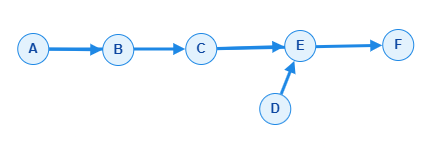

Calculando os caminhos, temos:
A → B → C → E → F

e o tempo, sendo de:
2 + 3 + 5 + 2 + 1 = 13

Na outra alternativa, temos:
A → B → D → E → F

e o tempo, sendo de:
2 + 3 + 4 + 2 + 1 = 12

De acordo com a teoria de Gerenciamento de Projetos (Caminho Crítico), o menor-maior tempo necessário para realizar todas as tarefas do projeto é determinado pelo caminho de maior duração (o gargalo do projeto).

Logo, o menor-maior tempo para concluir o projeto é de 13 e o caminho crítico é
A → B → C → E → F. Portanto, o projeto será concluído em 13 unidades de tempo.




